In [1]:
from ntk_utils import NTKHelper
from collections import OrderedDict

# Network
from nets import net_dict
import torch
from torch import nn
import numpy as np

net = nn.Sequential(*(net_dict['resnet-cifar']().getNets(
    [3, 32, 32],
    [10,],
)))

net_prev = nn.Sequential(*(net_dict['resnet-cifar']().getNets(
    [3, 32, 32],
    [10,],
)))

def translate_weight(w):
    original_state_dict = w['state_dict']

    translated = OrderedDict()
    for key in original_state_dict:
    
        if not key.startswith('net.'):
            continue
    
        newkey = ''
        if key.startswith('net.'):
            newkey = key[4:]
    
        translated[newkey] = original_state_dict[key]

    return translated

net.load_state_dict(
    translate_weight(torch.load("checkpoints/resnet18-cifar10-sgd/epoch=0399-val_acc_seen=0.86.ckpt")))
net_prev.load_state_dict(
    translate_weight(torch.load("checkpoints/resnet18-cifar10-sgd/epoch=0019-val_acc_seen=0.68.ckpt")))

net.eval()
net.cuda()

net_prev.eval()
net_prev.cuda()

conv1_type:cifar
no_maxpool:True
conv1_type:cifar
no_maxpool:True


Sequential(
  (0): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): Recorder(
      (wrappedLayer): ReLU()
      (dropout): Dropout(p=0.5, inplace=False)
    )
    (maxpool): MaxPool2d(kernel_size=1, stride=1, padding=0, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): Recorder(
          (wrappedLayer): ReLU()
          (dropout): Dropout(p=0.5, inplace=False)
        )
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): C

In [2]:
ntk_helper = NTKHelper(net)
ntk_helper_prev = NTKHelper(net_prev)

In [3]:
import torchvision
from torchvision import datasets
import torchvision.transforms as transforms

np.random.seed(42)

from openood.datasets.imglist_dataset import ImglistDataset
from openood.evaluation_api.preprocessor import get_default_preprocessor

prepro = get_default_preprocessor('imagenet')

id_dataset = ImglistDataset(
    name = 'test',
    imglist_pth = '/home/zhang/RP_ML/ttuq-openood/data/benchmark_imglist/imagenet/val_imagenet.txt',
    data_dir = '/home/zhang/RP_ML/ttuq-openood/data/images_largescale',
    num_classes = 1000,
    preprocessor = prepro,
    data_aux_preprocessor = prepro
)

N_train = 64
X_dataset = torch.utils.data.Subset(id_dataset, np.random.choice(len(id_dataset), N_train))

In [4]:
from torch.utils.data import DataLoader

X = DataLoader(X_dataset, batch_size = 2, shuffle = False)

_Oxx_diag_unscaled = ntk_helper.compute_ntk(
    X, X, batch_mode = 'pairwise', 
    x1_map = lambda b : b['data'], 
    x2_map = lambda b : b['data'],
    x1_scaling = lambda j : j,
    x2_scaling = lambda j : j
).detach().cpu().numpy()

_Oxx_diag_scaled = ntk_helper.compute_ntk(
    X, X, batch_mode = 'pairwise', 
    x1_map = lambda b : b['data'], 
    x2_map = lambda b : b['data'],
).detach().cpu().numpy()

_Oxx_diag_prev = ntk_helper_prev.compute_ntk(
    X, X, batch_mode = 'pairwise', 
    x1_map = lambda b : b['data'], 
    x2_map = lambda b : b['data'],
    x1_scaling = lambda j : j,
    x2_scaling = lambda j : j).detach().cpu().numpy()

In [5]:
from matplotlib import pyplot as plt

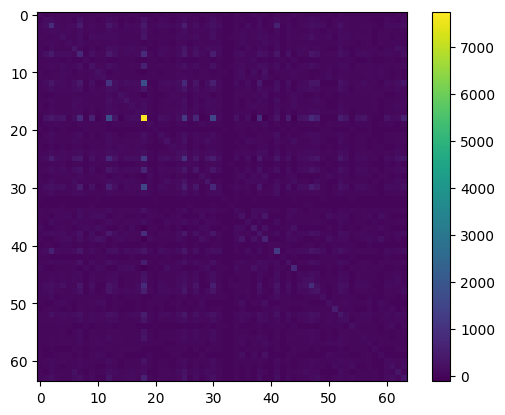

In [6]:
plt.imshow(_Oxx_diag_scaled)
plt.colorbar()

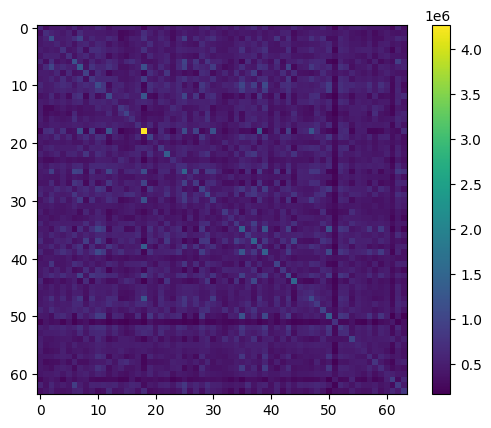

In [7]:
plt.imshow(_Oxx_diag_prev)
plt.colorbar()

In [8]:
import scipy

def compare(x, y):
    xx = x.flatten()
    yy = y.flatten()
    return scipy.stats.spearmanr(xx, yy)

print(compare(_Oxx_diag_prev, _Oxx_diag_unscaled))
print(compare(_Oxx_diag_prev, _Oxx_diag_scaled))

SignificanceResult(statistic=0.4890447777410866, pvalue=2.558660619741707e-245)
SignificanceResult(statistic=0.6702984865077029, pvalue=0.0)


In [ ]:
import os
ROOT = "../refactored-aaai25/checkpoints/resnet18-cifar10-sgd"
ckpt_fns = os.listdir(ROOT)
ckpt_fns.sort()
ckpts = [os.path.join(ROOT, c) for c in ckpt_fns]
# print(ckpts)

eps = [int(c[6:10]) for c in ckpt_fns]
acc = [float(c[-9:-5]) for c in ckpt_fns]
# print(list(zip(eps, ckpts)))
print(acc)

from tqdm.notebook import tqdm

_Oxx_diag_prevs = []

for pth in tqdm(ckpts):
    net_prev.load_state_dict(
        translate_weight(torch.load(pth)))
    ntk_helper_prev = NTKHelper(net_prev)

    _Oxx_diag_prev = ntk_helper_prev.compute_ntk(
        X, X, batch_mode = 'pairwise', 
        x1_map = lambda b : b['data'], 
        x2_map = lambda b : b['data'],
        x1_scaling = lambda j : j,
        x2_scaling = lambda j : j).detach().cpu().numpy()

    _Oxx_diag_prevs.append(_Oxx_diag_prev)

[0.0, 0.12, 0.32, 0.41, 0.44, 0.47, 0.5, 0.49, 0.53, 0.56, 0.57, 0.59, 0.68, 0.74, 0.79, 0.8, 0.82, 0.83, 0.83, 0.84, 0.84, 0.84, 0.84, 0.85, 0.85, 0.85, 0.85, 0.86, 0.85, 0.85, 0.85, 0.86, 0.85, 0.86, 0.86, 0.86, 0.86, 0.86, 0.85, 0.86, 0.86, 0.86, 0.86, 0.86, 0.86, 0.86, 0.87, 0.86, 0.86, 0.86, 0.86]


  0%|          | 0/51 [00:00<?, ?it/s]

In [14]:
unscaled_rs = [compare(_Oxx_diag_unscaled, oxx).statistic for oxx in _Oxx_diag_prevs]
scaled_rs = [compare(_Oxx_diag_scaled, oxx).statistic for oxx in _Oxx_diag_prevs]

<Figure size 210x150 with 0 Axes>

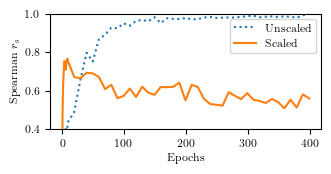

In [39]:
plt.style.use('./aaai25.mplstyle')
plt.tight_layout()

fig, ax = plt.subplots(figsize = (3.5, 1.5))

plt.clf()
plt.plot(eps, unscaled_rs, ':', label = "Unscaled")
plt.plot(eps, scaled_rs, label = "Scaled")
plt.ylim(0.4, 1.00)
plt.xlabel("Epochs")
plt.ylabel("Spearman $r_s$") # $(\hat{\Theta}_t; \tilde{\Theta})$
plt.legend()

plt.savefig("NTK-scaling-directvis.pdf", format="pdf", bbox_inches = 'tight')
plt.show()

In [17]:
_Oxx_diag_scaled.shape
torch.save({
    "Unscaled": _Oxx_diag_unscaled,
    "Scaled": _Oxx_diag_scaled,
    "All epochs unscaled": _Oxx_diag_prevs
}, "ResNet18-CIFAR10-NTKAnalysis-LayerwiseNorm.pkl")

In [ ]:
plt.scatter(_Oxx_diag_prev.flatten(), _Oxx_diag_unscaled.flatten())
plt.ylim(0.5e7, 1.2e7)

In [ ]:
plt.scatter(_Oxx_diag_prev.flatten(), _Oxx_diag_scaled.flatten())
plt.ylim(0, 400)